### Machine Learning Approach

In [2]:
import pandas as pd
import numpy as np
import json
import os
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import seaborn as sns

print("All imports successful")

All imports successful


In [3]:
# Path is relative to the notebook location (ml/ folder)
CSV_PATH = '../data/spotify_dataset.csv'

df = pd.read_csv(CSV_PATH)

print(f"Shape: {df.shape}")

Shape: (114000, 21)


In [4]:
print(f"\nColumns:")
df.columns.tolist()


Columns:


['Unnamed: 0',
 'track_id',
 'artists',
 'album_name',
 'track_name',
 'popularity',
 'duration_ms',
 'explicit',
 'danceability',
 'energy',
 'key',
 'loudness',
 'mode',
 'speechiness',
 'acousticness',
 'instrumentalness',
 'liveness',
 'valence',
 'tempo',
 'time_signature',
 'track_genre']

In [5]:
# Column mapping — exact names from dataset
TRACK_NAME_COL = 'track_name'
ARTIST_COL     = 'artists'
TRACK_ID_COL   = 'track_id'

FEATURES = [
    'danceability', 'energy', 'valence', 'tempo',
    'acousticness', 'instrumentalness', 'speechiness',
    'liveness', 'popularity'
]

# Drop rows with missing values in feature columns only
df = df.dropna(subset=FEATURES).reset_index(drop=True)

# Remove duplicate tracks 
df = df.drop_duplicates(subset=[TRACK_ID_COL]).reset_index(drop=True)

# Normalize tempo (0-1 scale, same as other features)
df['tempo'] = df['tempo'] / df['tempo'].max()

# Normalize popularity (its 0-100, bring to 0-1)
df['popularity'] = df['popularity'] / 100.0

print(f"Clean dataset shape: {df.shape}")
print(f"Unique tracks: {df[TRACK_ID_COL].nunique()}")
print(f"\nFeature value ranges (all should be 0.0 - 1.0):")
print(df[FEATURES].agg(['min','max']).round(3))

Clean dataset shape: (89741, 21)
Unique tracks: 89741

Feature value ranges (all should be 0.0 - 1.0):
     danceability  energy  valence  tempo  acousticness  instrumentalness  \
min         0.000     0.0    0.000    0.0         0.000               0.0   
max         0.985     1.0    0.995    1.0         0.996               1.0   

     speechiness  liveness  popularity  
min        0.000       0.0         0.0  
max        0.965       1.0         1.0  


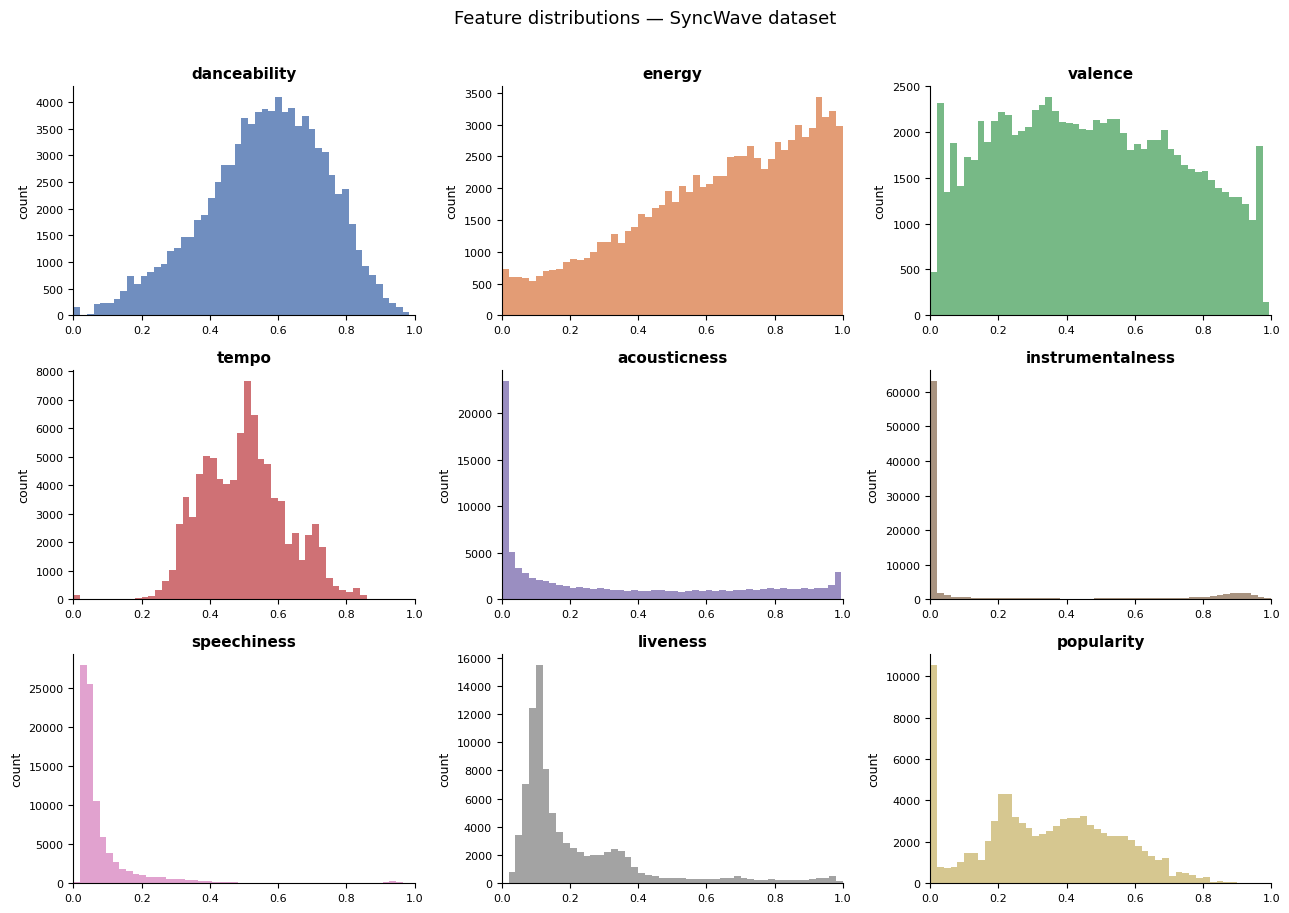

In [6]:
fig, axes = plt.subplots(3, 3, figsize=(13, 9))
axes = axes.flatten()

colors = ['#4C72B0','#DD8452','#55A868','#C44E52',
          '#8172B2','#937860','#DA8BC3','#8C8C8C','#CCB974']

for i, feature in enumerate(FEATURES):
    axes[i].hist(df[feature], bins=50, color=colors[i], alpha=0.8, edgecolor='none')
    axes[i].set_title(feature, fontsize=11, fontweight='bold')
    axes[i].set_xlim(0, 1)
    axes[i].set_ylabel('count', fontsize=9)
    axes[i].tick_params(labelsize=8)
    axes[i].spines['top'].set_visible(False)
    axes[i].spines['right'].set_visible(False)

plt.suptitle('Feature distributions — SyncWave dataset', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

In [7]:
# Final summary
print("=" * 45)
print(f"  Total songs    : {len(df):,}")
print(f"  Features used  : {len(FEATURES)}")
print(f"  Genres present : {df['track_genre'].nunique()}")
print("=" * 45)

  Total songs    : 89,741
  Features used  : 9
  Genres present : 113


### K-Means Clustering

In [8]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# StandardScaler: zero mean, unit variance
# Better than MinMax for K-Means — handles outliers well
scaler = StandardScaler()
X = scaler.fit_transform(df[FEATURES])

print(f"Scaled matrix shape : {X.shape}")
print(f"Mean : {X.mean(axis=0).round(3)}")
print(f"Std : {X.std(axis=0).round(3)}")

Scaled matrix shape : (89741, 9)
Mean : [-0.  0.  0. -0.  0. -0.  0. -0. -0.]
Std : [1. 1. 1. 1. 1. 1. 1. 1. 1.]


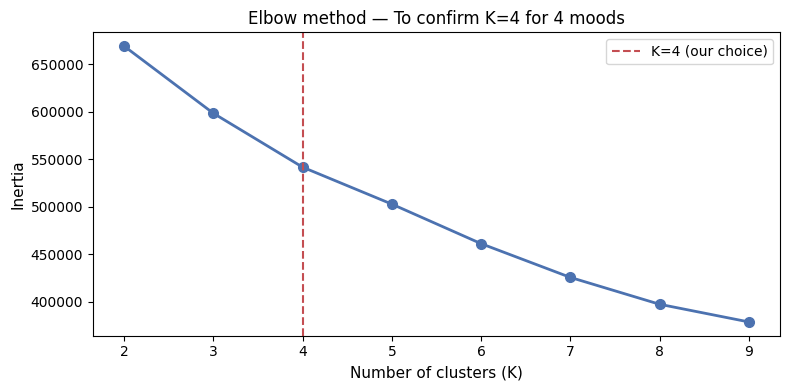

In [9]:
# Try K from 2 to 9, plot inertia to confirm K=4 is right
inertias = []
K_range = range(2, 10)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X)
    inertias.append(km.inertia_)

plt.figure(figsize=(8, 4))
plt.plot(K_range, inertias, 'o-', color='#4C72B0', linewidth=2, markersize=7)
plt.axvline(x=4, color='#C44E52', linestyle='--', linewidth=1.5, label='K=4 (our choice)')
plt.xlabel('Number of clusters (K)', fontsize=11)
plt.ylabel('Inertia', fontsize=11)
plt.title('Elbow method — To confirm K=4 for 4 moods', fontsize=12)
plt.legend()
plt.xticks(K_range)
plt.tight_layout()
plt.show()

### K=4 confirmed from Elbow Method.

In [ ]:
# Train model
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
df['cluster'] = kmeans.fit_predict(X)

# Check how many songs landed in each cluster
counts = df['cluster'].value_counts().sort_index()
print("Songs per cluster:")
for cluster_id, count in counts.items():
    print(f"  Cluster {cluster_id}: {count:,} songs")

Songs per cluster:
  Cluster 0: 7,131 songs
  Cluster 1: 35,755 songs
  Cluster 2: 20,366 songs
  Cluster 3: 26,489 songs


In [11]:
# Decode centroids back to original scale for readability
centroids = pd.DataFrame(
    scaler.inverse_transform(kmeans.cluster_centers_),
    columns=FEATURES
)
centroids.index.name = 'cluster'

print("Centroid values per cluster (original scale):\n")
print(centroids[['valence', 'energy', 'danceability',
                  'acousticness', 'tempo', 'instrumentalness']].round(3))

print("\n--- Mood assignment logic ---")
print("High valence + high energy               → Energetic")
print("High valence + low energy + danceable    → Romantic")
print("Low  valence + low energy + high acoustic→ Sad")
print("Mid  valence + mid energy                → Chill")

Centroid values per cluster (original scale):

         valence  energy  danceability  acousticness  tempo  instrumentalness
cluster                                                                      
0          0.488   0.738         0.524         0.371  0.493             0.079
1          0.679   0.690         0.690         0.257  0.491             0.054
2          0.293   0.285         0.451         0.778  0.448             0.315
3          0.318   0.800         0.486         0.068  0.559             0.252

--- Mood assignment logic ---
High valence + high energy               → Energetic
High valence + low energy + danceable    → Romantic
Low  valence + low energy + high acoustic→ Sad
Mid  valence + mid energy                → Chill


In [12]:
# Mood map based on centroid analysis
mood_map = {
    0: 'Chill',
    1: 'Energetic',
    2: 'Sad',
    3: 'Romantic'
}

df['mood'] = df['cluster'].map(mood_map)

print("Songs per mood:")
for mood in ['Chill', 'Romantic', 'Energetic', 'Sad']:
    count = len(df[df['mood'] == mood])
    bar   = '█' * (count // 1000)
    print(f"  {mood:12}: {count:6,}  {bar}")

Songs per mood:
  Chill       :  7,131  ███████
  Romantic    : 26,489  ██████████████████████████
  Energetic   : 35,755  ███████████████████████████████████
  Sad         : 20,366  ████████████████████


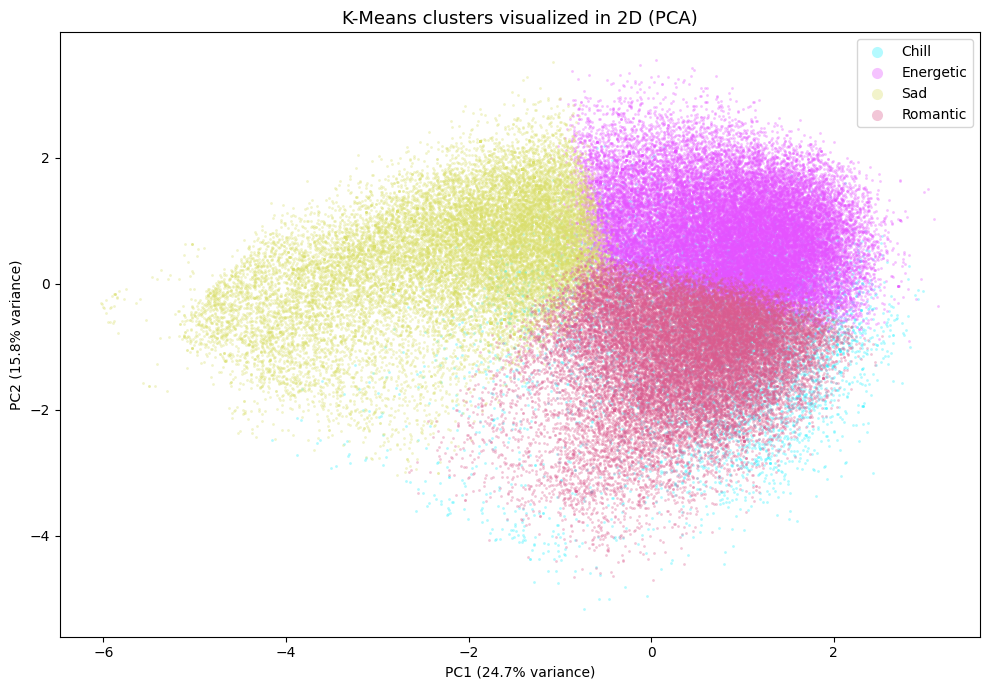

Variance explained by 2 components: 40.5%


In [13]:
from sklearn.decomposition import PCA

# Compress 9 features → 2D only for visualization
pca = PCA(n_components=2, random_state=42)
coords = pca.fit_transform(X)

mood_colors = {
    'Chill'    : "#2AF1FF",
    'Energetic': "#E553FF",
    'Sad'      : "#DADF6B",
    'Romantic' : "#DB5C8F"
}

plt.figure(figsize=(10, 7))

for mood, color in mood_colors.items():
    mask = df['mood'] == mood
    plt.scatter(
        coords[mask, 0],
        coords[mask, 1],
        c=color, label=mood,
        alpha=0.35, s=4, linewidths=0
    )

plt.title('K-Means clusters visualized in 2D (PCA)', fontsize=13)
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)', fontsize=10)
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)', fontsize=10)
plt.legend(markerscale=4, fontsize=10)
plt.tight_layout()
plt.show()

print(f"Variance explained by 2 components: "
      f"{sum(pca.explained_variance_ratio_)*100:.1f}%")

In [14]:
KEEP_COLS = [TRACK_ID_COL, TRACK_NAME_COL, ARTIST_COL, 'album_name', 'popularity', 'mood',
             'danceability', 'energy', 'valence', 'tempo',
             'acousticness', 'instrumentalness', 'speechiness', 'liveness']

clustered = {}
for mood in ['Chill', 'Romantic', 'Energetic', 'Sad']:
    mood_df = df[df['mood'] == mood][KEEP_COLS].copy()

    for col in ['danceability', 'energy', 'valence', 'tempo',
                'acousticness', 'instrumentalness', 'speechiness', 'liveness']:
        mood_df[col] = mood_df[col].round(3)

    mood_df = mood_df.sort_values('popularity', ascending=False)
    clustered[mood] = mood_df.to_dict(orient='records')

OUTPUT_PATH = '../data/clustered_songs.json'
with open(OUTPUT_PATH, 'w', encoding='utf-8') as f:
    json.dump(clustered, f, ensure_ascii=False, indent=2)

print("clustered_songs.json saved.")
print(f"\nSong counts:")
for mood, songs in clustered.items():
    print(f"  {mood:12}: {len(songs):,} songs")

size_kb = os.path.getsize(OUTPUT_PATH) / 1024
print(f"\nFile size: {size_kb:,.0f} KB  ({size_kb/1024:.1f} MB)")

clustered_songs.json saved.

Song counts:
  Chill       : 7,131 songs
  Romantic    : 26,489 songs
  Energetic   : 35,755 songs
  Sad         : 20,366 songs

File size: 40,244 KB  (39.3 MB)


In [24]:
import pickle

with open('../data/kmeans_model.pkl', 'wb') as f:
    pickle.dump(kmeans, f)

with open('../data/scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

print("kmeans_model.pkl saved")
print("scaler.pkl        saved")

# Verification — predict one real song
sample       = df[FEATURES].iloc[0].values.reshape(1, -1)
sample_scaled = scaler.transform(sample)
pred_cluster  = kmeans.predict(sample_scaled)[0]
pred_mood     = mood_map[pred_cluster]

print(f"\nVerification:")
print(f"  Track  : {df[TRACK_NAME_COL].iloc[0]}")
print(f"  Artist : {df[ARTIST_COL].iloc[0]}")
print(f"  Mood   : {pred_mood}")

kmeans_model.pkl saved
scaler.pkl        saved

Verification:
  Track  : Comedy
  Artist : Gen Hoshino
  Mood   : Energetic


In [15]:
print("=" * 50)
print(" K-Means clustering done.")
print("=" * 50)

for mood in ['Chill', 'Romantic', 'Energetic', 'Sad']:
    count = len(df[df['mood'] == mood])
    bar   = '█' * (count // 2000)
    print(f"  {mood:12}: {count:6,}  {bar}")

print()
print("Files saved to data/:")
files = ['clustered_songs.json', 'kmeans_model.pkl', 'scaler.pkl']
for fname in files:
    path = f'../data/{fname}'
    if os.path.exists(path):
        size = os.path.getsize(path) / 1024
        print(f"  ✓ {fname:28} {size:>8,.0f} KB")
    else:
        print(f"  ✗ {fname} — NOT FOUND")

print()

 K-Means clustering done.
  Chill       :  7,131  ███
  Romantic    : 26,489  █████████████
  Energetic   : 35,755  █████████████████
  Sad         : 20,366  ██████████

Files saved to data/:
  ✓ clustered_songs.json           40,244 KB
  ✓ kmeans_model.pkl                  351 KB
  ✓ scaler.pkl                          1 KB



### LSTM Prediction Model

In [20]:
import random

# ── Mood encoding — 
MOODS    = ['Chill', 'Energetic', 'Sad', 'Romantic']
mood2idx = {m: i for i, m in enumerate(MOODS)}
idx2mood = {i: m for i, m in enumerate(MOODS)}

print("Mood encoding (matches K-Means cluster IDs):")
for m, i in mood2idx.items():
    print(f"  {m:12} → {i}")

# ── Realistic mood transition rules ───────────────────────
transitions = {
    'Chill'    : ['Chill', 'Chill', 'Romantic', 'Energetic'],
    'Energetic': ['Energetic', 'Energetic', 'Chill', 'Romantic'],
    'Sad'      : ['Sad', 'Sad', 'Chill', 'Romantic'],
    'Romantic' : ['Romantic', 'Romantic', 'Chill', 'Sad']
}

def generate_sequence(length=200):
    seq = [random.choice(MOODS)]
    for _ in range(length - 1):
        seq.append(random.choice(transitions[seq[-1]]))
    return seq

# Generate 300 synthetic user sessions
random.seed(42)
all_sequences = [generate_sequence(200) for _ in range(300)]

print(f"\nGenerated  : {len(all_sequences)} sequences")
print(f"Length each: {len(all_sequences[0])} moods")
print(f"\nSample (first 15):")
print(" → ".join(all_sequences[0][:15]))

Mood encoding (matches K-Means cluster IDs):
  Chill        → 0
  Energetic    → 1
  Sad          → 2
  Romantic     → 3

Generated  : 300 sequences
Length each: 200 moods

Sample (first 15):
Chill → Chill → Romantic → Romantic → Romantic → Romantic → Romantic → Romantic → Sad → Sad → Sad → Sad → Sad → Sad → Sad


In [21]:
import numpy as np
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Embedding
from tensorflow.keras.utils import to_categorical

WINDOW = 5   # last 5 moods → predict next

# ── Build sliding window dataset ────────────────
X_list, y_list = [], []

for seq in all_sequences:
    encoded = [mood2idx[m] for m in seq]
    for i in range(len(encoded) - WINDOW):
        X_list.append(encoded[i : i + WINDOW])
        y_list.append(encoded[i + WINDOW])

X = np.array(X_list)
y = to_categorical(y_list, num_classes=4)

print(f"Training samples : {X.shape[0]:,}")
print(f"Input shape      : {X.shape}")
print(f"Output shape     : {y.shape}")

# ── Lightweight LSTM ─────────────────────────────
model = Sequential([
    Embedding(input_dim=4, output_dim=8, input_length=WINDOW),
    LSTM(32),
    Dense(16, activation='relu'),
    Dense(4,  activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

# ── Train ────────────────
history_log = model.fit(
    X, y,
    epochs           = 30,
    batch_size       = 64,
    validation_split = 0.1,
    verbose          = 1
)

final_acc = history_log.history['accuracy'][-1]
final_val = history_log.history['val_accuracy'][-1]

print(f"\nFinal train accuracy : {final_acc:.3f}")
print(f"Final val accuracy   : {final_val:.3f}")

Training samples : 58,500
Input shape      : (58500, 5)
Output shape     : (58500, 4)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
823/823 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.4653 - loss: 1.1021 - val_accuracy: 0.5039 - val_loss: 1.0432
Epoch 2/30
823/823 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.4976 - loss: 1.0476 - val_accuracy: 0.5039 - val_loss: 1.0396
Epoch 3/30
823/823 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.4978 - loss: 1.0453 - val_accuracy: 0.5039 - val_loss: 1.0404
Epoch 4/30
823/823 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.4978 - loss: 1.0444 - val_accuracy: 0.5039 - val_loss: 1.0405
Epoch 5/30
823/823 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.4978 - loss: 1.0439 - val_accuracy: 0.5039 - val_loss: 1.0437
Epoch 6/30
823/823 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.4978 - loss: 1.0439 - val_accuracy: 0.5039 - val_loss: 1.0380
Epoch 7/30
823/823 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.4978 - loss: 1.0431 - val_accuracy: 0.5039 - val_loss: 1.0407
Epoch 8/30
823/823 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.4978 - loss: 1.0432 - val_accuracy: 0.

In [22]:
def predict_next_mood_lstm(last_5_moods):
    """
    Takes last 5 mood strings → returns predicted next mood string.
    Falls back to weighted frequency if history < 5.
    """
    if len(last_5_moods) < 5:
        # weighted fallback — recent moods count more
        weights = {mood: 0 for mood in MOODS}
        for weight, mood in enumerate(last_5_moods, start=1):
            weights[mood] += weight
        return max(weights, key=weights.get)

    encoded  = np.array([[mood2idx[m] for m in last_5_moods[-5:]]])
    probs    = model.predict(encoded, verbose=0)[0]
    pred_idx = np.argmax(probs)
    return idx2mood[pred_idx]

# ── Test cases ─────────────────────────────────────────────
test_cases = [
    ['Sad',       'Sad',       'Sad',       'Chill',     'Chill'    ],
    ['Energetic', 'Energetic', 'Energetic', 'Energetic', 'Romantic' ],
    ['Romantic',  'Chill',     'Chill',     'Romantic',  'Romantic' ],
    ['Sad',       'Sad',       'Chill',     'Chill',     'Energetic'],
    ['Chill',     'Chill',     'Chill',     'Chill',     'Chill'    ],
]

print("Prediction tests (window=5):")
print("-" * 50)
for tc in test_cases:
    pred = predict_next_mood_lstm(tc)
    print(f"  Input : {' → '.join(tc)}")
    print(f"  Pred  : {pred}")
    print()


Prediction tests (window=5):
--------------------------------------------------
  Input : Sad → Sad → Sad → Chill → Chill
  Pred  : Chill

  Input : Energetic → Energetic → Energetic → Energetic → Romantic
  Pred  : Romantic

  Input : Romantic → Chill → Chill → Romantic → Romantic
  Pred  : Romantic

  Input : Sad → Sad → Chill → Chill → Energetic
  Pred  : Energetic

  Input : Chill → Chill → Chill → Chill → Chill
  Pred  : Chill



In [23]:
# ── Export mood_predictions.json ───────────────────────────
predictions_export = {
    "model"      : "lstm",
    "window_size": WINDOW,
    "moods"      : MOODS,
    "mood2idx"   : mood2idx,
    "description": "Predicts next mood from last 5 mood history",
    "sample_predictions": [
        {"input": tc, "predicted": predict_next_mood_lstm(tc)}
        for tc in test_cases
    ]
}

with open('../data/mood_predictions.json', 'w') as f:
    json.dump(predictions_export, f, indent=2)

print("mood_predictions.json saved.")

mood_predictions.json saved.


In [25]:
# Save LSTM model
model.save('../data/lstm_model.keras')
print("lstm_model.keras saved")

# Save mood encoding for services.py
encoding_export = {
    "mood2idx" : mood2idx,
    "idx2mood" : {str(k): v for k, v in idx2mood.items()},
    "moods"    : MOODS,
    "window"   : WINDOW
}
with open('../data/moods.json', 'w') as f:
    json.dump(encoding_export, f, indent=2)

print("moods.json saved")
print()
print("=" * 50)
print("LSTM mood prediction done.")
print("=" * 50)

files = ['lstm_model.keras', 'mood_predictions.json', 'moods.json']
for fname in files:
    path = f'../data/{fname}'
    if os.path.exists(path):
        size = os.path.getsize(path) / 1024
        print(f"  ✓ {fname:28} {size:>8,.1f} KB")
    else:
        print(f"  ✗ {fname} — NOT FOUND")

print()

lstm_model.keras saved
moods.json saved

LSTM mood prediction done.
  ✓ lstm_model.keras                100.8 KB
  ✓ mood_predictions.json             1.1 KB
  ✓ moods.json                        0.3 KB

